<a href="https://colab.research.google.com/github/KULDEEPSONI-source/MACHINE-LEARNING/blob/main/polnomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures , StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline


In [45]:
X=6*np.random.rand(200,1)-3
y = 0.8*X**2 + 0.9*X + 2 + np.random.randn(200,1)
#y=2+ 0.9X+0.8X^2+noise
print(X)

[[-2.53017487]
 [-1.19951537]
 [-2.34422146]
 [-1.43558379]
 [ 2.01208094]
 [ 1.8230871 ]
 [ 1.14726107]
 [-2.14064655]
 [ 1.17589119]
 [-0.34512633]
 [-1.18413075]
 [-0.4208454 ]
 [-0.65516527]
 [ 2.41049911]
 [-2.83989793]
 [-0.56249094]
 [-1.34899594]
 [-2.80436944]
 [-2.65841987]
 [-1.73082241]
 [-2.90969337]
 [ 0.36685427]
 [ 0.27972803]
 [-0.06905281]
 [ 0.51866483]
 [-2.6721265 ]
 [-0.97780256]
 [-2.24082908]
 [ 1.97878367]
 [-1.34443557]
 [ 2.05277212]
 [ 2.20068914]
 [-2.5048397 ]
 [-2.19288951]
 [-2.44419097]
 [ 0.81568748]
 [ 0.10064147]
 [ 0.18804349]
 [ 0.45199701]
 [ 2.81539087]
 [ 1.22626044]
 [ 2.60742009]
 [-0.74671794]
 [ 0.05004835]
 [ 0.44640996]
 [-1.02834019]
 [-2.74457985]
 [-1.19813677]
 [-2.12022482]
 [ 2.23321924]
 [ 1.36258076]
 [ 0.76617041]
 [-2.56202081]
 [ 1.43107046]
 [ 2.54028079]
 [-1.61409964]
 [-0.18557556]
 [-0.31693831]
 [ 0.32320422]
 [-1.54400506]
 [-1.74235567]
 [-2.55040794]
 [-0.05949338]
 [-1.80628087]
 [ 2.85256968]
 [ 0.93755261]
 [ 2.14664

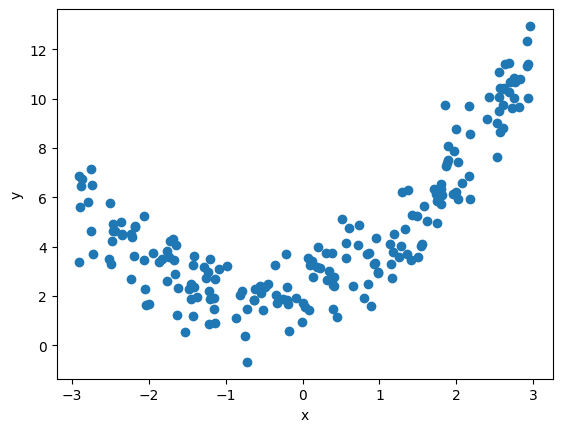

In [10]:
plt.scatter(X,y)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [12]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=3)

In [14]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)
r2_score_lr = r2_score(y_test, y_pred)
print("R2-score is: ", r2_score_lr)


R2-score is:  0.26811308651992616


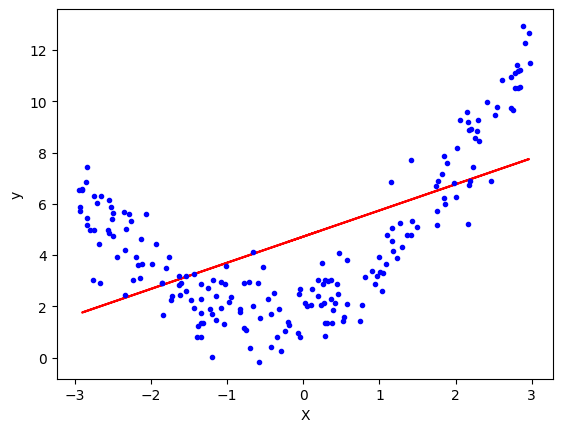

In [49]:
plt.plot(X_train, model.predict(X_train), color='r')
plt.plot(X, y, 'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

#### **Applying Polynomial Linear Regression**

In the context of scikit-learn's `PolynomialFeatures`, these two parameters are what define the complexity and mathematical structure of the features you are generating to feed into your model (often used before a `LinearRegression` step).

---

### 1. `degree`

The `degree` parameter determines the power to which your input features ($x$) are raised. It controls the "complexity" of the polynomial expansion.

* **How it works:** If you have a single feature $x_1$, a degree of 2 creates features for $x_1^1$ and $x_1^2$. If you have two features, $x_1$ and $x_2$, a degree of 2 creates: $x_1, x_2, x_1^2, x_2^2,$ and the interaction term $x_1 \cdot x_2$.
* **The Effect:**
* **Degree 1:** Keeps the features as they are (linear).
* **Degree 2 (or higher):** Allows the model to capture non-linear relationships (curves) in your data.


* **Trade-off:**
* **High Degree:** Increases the model's ability to fit complex patterns (reducing bias), but risks **overfitting** and makes the model highly sensitive to noise.
* **Low Degree:** Keeps the model simple and more generalizable, but may lead to **underfitting** if the true relationship in your data is curved.



---

### 2. `include_bias`

The `include_bias` parameter (default is `True`) controls whether the "intercept" term is added to your generated features.

* **What it is:** In mathematics, this is the $x^0$ term (or simply $1$).
* **How it works:**
* **`include_bias=True`:** Adds a column of 1s to your output array.
* **`include_bias=False`:** Omits this column.


* **Why it matters:**
* If you are going to pass these features into a `LinearRegression` model that has `fit_intercept=True` (which is the default), you typically set `include_bias=False` to avoid redundant intercept columns.
* However, if you are building a custom model or using a regressor that doesn't handle the intercept automatically, you must ensure `include_bias=True` so that the model can account for the vertical shift (the "offset") of your regression line/curve.



---

### Summary Table

| Parameter | What it does | Impact |
| --- | --- | --- |
| **`degree`** | Sets the maximum power for features. | High degree = more curves/complex; Low degree = simpler/linear. |
| **`include_bias`** | Adds a column of 1s (intercept term). | `True` = includes the Y-axis intercept; `False` = excludes it. |

### Pro-Tip for your Workflow

Since you are likely using this for a pipeline:

```python
# A common pattern
poly = PolynomialFeatures(degree=2, include_bias=False)
model = LinearRegression(fit_intercept=True) # Let the model handle the intercept

```

Using `include_bias=False` here keeps your feature matrix cleaner and avoids potential multicollinearity issues or "duplicate constant" warnings in some libraries.



In [20]:
poly = PolynomialFeatures(degree=2, include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [21]:
print(X_train[0])

[-0.20563898]


In [22]:
print(X_train_trans[0])

[ 1.         -0.20563898  0.04228739]


In [23]:
lr = LinearRegression()
lr.fit(X_train_trans, y_train)

LinearRegression()

In [24]:
y_pred = lr.predict(X_test_trans)

In [25]:
r2_score(y_test,y_pred)

0.8069250442168968

In [26]:
print(lr.coef_)

[[0.         0.90602683 0.76764005]]


In [27]:
print(lr.intercept_)

[2.17796862]


This code snippet is the standard way to visualize how a machine learning model "sees" a non-linear space. You are essentially generating a smooth curve by creating a set of synthetic points and passing them through your trained polynomial transformation.

Here is the breakdown of what each part is doing:

---

### 1. `np.linspace(-3, 3, 200)`

This function generates a sequence of **200 evenly spaced numbers** between -3 and 3.

* **Why do this?** If you only predict using your original training data, your plot will look jagged if the data is sparse. By generating a dense, synthetic set of points (a "grid"), you create a smooth, continuous line when you plot the results.
* **The range (-3 to 3):** This should generally cover the range of your original input data ($X$) so that you are visualizing the model's behavior where it actually learned, rather than extrapolating into unknown territory.

### 2. `.reshape(200, 1)`

`linspace` returns a 1D array (a simple list of numbers). Scikit-learn models, however, expect a **2D array** (a matrix where each row is a sample and each column is a feature).

* **The structure:** The `200` represents the number of samples, and the `1` represents the number of features. Even if you only have one feature, the model requires this 2D structure to function correctly.

---

### 3. `poly.transform(X_new)`

This is a critical step. Your model was trained on **polynomial features** ($x, x^2, x^3...$), not the original raw $x$ values.

* **Consistency:** `poly` must be the **exact same instance** of `PolynomialFeatures` that you used to transform your training data.
* **The Transformation:** It takes your 200 raw points and maps them into the higher-dimensional space.
* If your `degree` is 2, it converts your column of $x$ values into two columns: one for $x$ and one for $x^2$.


* **Why not `fit_transform`?** You **must** use `.transform()`, not `.fit_transform()`. You already "fit" the transformer on your original data (calculating how to scale or arrange the powers); now you are just applying that same logic to your new points.

---

### Summary of the Flow

1. **`np.linspace`**: Creates the "画布" (canvas)—the x-coordinates where you want to draw the prediction curve.
2. **`reshape`**: Formats the canvas to meet the model's requirements.
3. **`poly.transform`**: "Polynomial-izes" the canvas so the model can understand it.
4. **`lr.predict`**: Calculates the predicted $y$ values for those polynomial features, resulting in a smooth curve.

**Visualizing the result:**
When you eventually run `plt.plot(X_new, y_new)`, you will see a smooth curve because the `LinearRegression` model is calculating the values for those 200 points based on the polynomial features you generated.


In [28]:
X_new = np.linspace(-3,3,200).reshape(200,1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

This code block is the **final visualization stage**. You are taking the "model's brain" (the predictions we just calculated) and overlaying it onto your actual data to see how well it learned.

Here is the breakdown of how this plot is constructed:

---

### 1. The Model's Prediction Line (`"r-"`)

```python
plt.plot(X_new, y_new, "r-", linewidth=2, label='Predictions')

```

* **`X_new, y_new`**: This plots the smooth curve we generated using `np.linspace` and `poly.transform`.
* **`"r-"`**: This is a shorthand format string:
* `r`: Sets the color to **red**.
* `-`: Sets the line style to a **solid line**.


* **`linewidth=2`**: Makes the prediction line thicker so it stands out against the data points.

### 2. The Data Points (`"b."` and `"g."`)

```python
plt.plot(X_train, y_train, "b.", label='Training')
plt.plot(X_test, y_test, "g.", label='Test')

```

* **`"b."` / `"g."**`: These are also shorthand:
* `b`/`g`: Colors the points **blue** (training) and **green** (test).
* `.`: Tells Matplotlib to plot these as **individual dots** (scatter) rather than connecting them with lines.


* **Why use different colors?** This is a best practice. It helps you visually confirm if the model is generalizing well. If the red line fits the blue dots but completely misses the green dots, your model is **overfitting** (memorizing the training data instead of learning the pattern).

### 3. The Metadata & Display

```python
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

```

* **`xlabel`/`ylabel**`: Adds labels to your axes. Always include these—they are essential for making your plots readable and professional.
* **`plt.legend()`**: This automatically pulls the `label` arguments from the three `plot` lines and creates a key in the corner of your graph so the viewer knows what the colors represent.
* **`plt.show()`**: This command renders the final figure in your output console or notebook.

---

### What to look for in your plot:

* **Underfitting:** If the red line is a straight line and the data is clearly curved, your `degree` is too low.
* **Overfitting:** If the red line snakes wildly to hit every single blue dot but misses the green test dots, your `degree` is too high (the model is just "connecting the dots").
* **Good Fit:** The red line should follow the general "trend" or "flow" of both the blue and green dots, even if it doesn't pass perfectly through every single one.

Since you are likely working on your **BYOP (Bring Your Own Project) capstone** or another technical assignment, this visual is exactly what you would include in a report to justify why you chose a specific `degree` for your model.



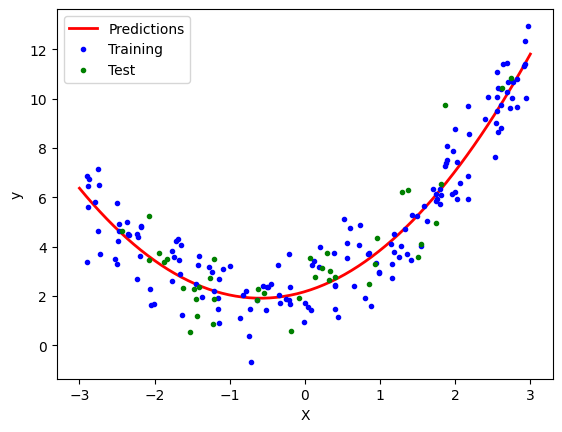

In [51]:
plt.plot(X_new,y_new, "r-", linewidth=2,label='Predictions')
plt.plot(X_train,y_train, "b.",label='Training')
plt.plot(X_test,y_test, "g.",label='Test')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

This function is a sophisticated **hyperparameter exploration tool**. It automates the process of creating, scaling, and training a polynomial model so you can visually compare how different `degree` values affect your fit.

Here is the breakdown of every component in your function:

---

### 1. The Setup & Pipeline

Instead of manually transforming data, you are using a **`Pipeline`**. This is professional-grade practice because it prevents data leakage and ensures that the same transformations are applied during both training and inference.

* **`PolynomialFeatures(degree=degree, include_bias=False)`**: This generates the polynomial combinations ($x, x^2, x^3, \dots$). By using `include_bias=False`, you allow the `LinearRegression` model to handle the intercept independently.
* **`StandardScaler()`**: This is **crucial**. As you increase the `degree`, the range of $x^n$ grows exponentially (e.g., if $x=3$, $x^2=9$ but $x^{10} \approx 59,000$). Scaling puts all these features on a similar scale (mean=0, variance=1), which helps the linear regression model converge correctly and prevents the features with huge values from dominating the model.
* **`LinearRegression()`**: The final stage of the pipeline that finds the "best fit" coefficients for your polynomial features.

---

### 2. The Logic Flow

1. **`X_new` generation**: Creates a consistent range from -3 to 3. This acts as your "test bed" to see how the model behaves across the entire input space.
2. **`pipeline.fit(X, y)`**: This is where the magic happens. The pipeline takes your raw $X$ data, performs the polynomial expansion, scales those features, and then fits the linear regression model to the target $y$.
3. **`y_newbig = pipeline.predict(X_new)`**: You feed the raw `X_new` into the pipeline. Because it's a pipeline, it automatically knows to transform and scale those new points *exactly* the way it did during the training phase.

---

### 3. The Visualization

* **`plt.plot(..., 'r', ...)`**: Draws the learned polynomial curve in red.
* **`plt.plot(X_train, y_train, "b.", ...)` & `plt.plot(X_test, y_test, "g.", ...)**`: These scatter plots allow you to compare the red line (the model's hypothesis) against your actual ground-truth data.
* **`plt.axis([-3, 3, 0, 10])`**: This **locks the view**. This is a great decision. By fixing the axis, you can compare a "Degree 1" plot to a "Degree 10" plot without the graph "jumping around" or rescaling. It allows you to see the true impact of the complexity.

---

### A Note on your code

There is one small inconsistency to watch out for:

* You have a line `X_new_poly = poly.transform(X_new)` at the top, but you don't actually use `X_new_poly` later—you pass the raw `X_new` directly into the `polynomial_regression` pipeline.
* **Recommendation:** You can safely remove the `X_new_poly` line, as the `Pipeline` handles the transformation internally inside `predict()`.

### Why this is perfect for your learning:

This function is a perfect "lab experiment." You can now loop through different degrees to see the "Bias-Variance Tradeoff" in real-time:

```python
# Try calling it for different degrees to see the behavior change!
for d in [1, 2, 10]:
    polynomial_regression(d)

```



A **Pipeline** in `scikit-learn` is a tool used to chain together multiple data processing steps and a machine learning model into a single, cohesive unit.

In your previous code, you manually managed the `PolynomialFeatures`, then the `StandardScaler`, and then the `LinearRegression`. If you forgot to scale your test data exactly like your training data, or if you accidentally used different degrees, your model would fail.

**A Pipeline automates this entire sequence.**

---

### 1. How it works

Think of a Pipeline as a **factory assembly line**. You put raw data in one end, and it travels through a sequence of "stations" (transformers) before reaching the final "station" (the model/estimator).

When you call `pipeline.fit(X, y)`:

1. **Station 1 (Transformer):** The pipeline calls `fit_transform()` on the first step.
2. **Station 2 (Transformer):** It takes the output of the first step and calls `fit_transform()` on the second step.
3. **Final Station (Estimator):** It takes the final transformed data and calls `fit()` on your model.

When you later call `pipeline.predict(X_new)`:

* The pipeline automatically applies the **exact same** transformations (using the parameters learned during `fit`) to your new data, then passes that result to the model for a prediction.

---

### 2. Why it is a "Must-Have" for your projects

* **Prevents Data Leakage:** This is the biggest reason. It ensures that your test data is transformed using the rules (mean/std dev) learned **only** from the training data.
* **Cleaner Code:** Instead of managing 4–5 variables (`X_train_trans`, `X_test_trans`, `poly`, `scaler`, `lr`), you only manage one: `pipeline`.
* **Easier Hyperparameter Tuning:** If you use `GridSearchCV` to find the best `degree` for your polynomial regression, the Pipeline makes it simple to test different degrees across the entire assembly line at once.

---

### 3. Your code, converted to a Pipeline

Here is how your logic looks when it is "professionalized" using a Pipeline:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

# Assemble the assembly line
model_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# Training: Everything happens in one line!
model_pipeline.fit(X_train, y_train)

# Inference: The pipeline automatically transforms X_test
# using the 'poly' and 'scaler' rules from the training set.
predictions = model_pipeline.predict(X_test)

```


In [59]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    # X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    Polynomial_Regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    Polynomial_Regression.fit(X, y)
    y_newbig = Polynomial_Regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

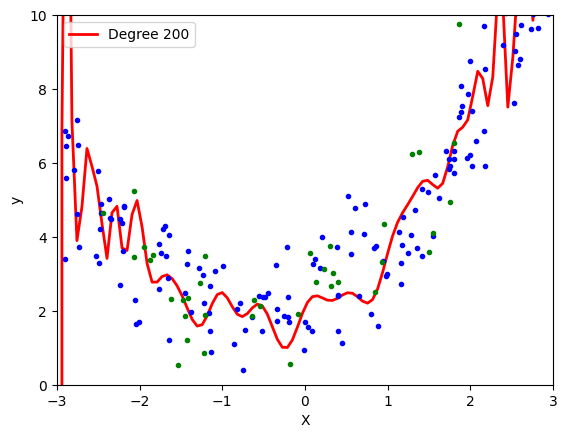

In [60]:
polynomial_regression(200)

In [32]:
poly.powers_

array([[0],
       [1],
       [2]])

In [33]:
# 3D polynomial regression

x = 7*np.random.rand(100,1)-2.8
y = 7*np.random.rand(100,1)-2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.rand(100,1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [34]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df,x=x.ravel(), y=y.ravel(), z = z.ravel())
fig.show()